# Módulo 1 — Diagnóstico operacional (Rappi)

Dataset: `data/rappi_delivery_case_data.xlsx` en la raíz del proyecto — 30 días × 24 h × 14 zonas. La primera celda localiza automáticamente esa ruta (sirve en VS Code con workspace en `caso_tecnico` o al abrir solo la carpeta `notebooks/`).

**Métrica:** $\text{ratio} = \text{ORDERS}/\text{CONNECTED_RT}$.  
**Saturación:** ratio > 1.8 · **Sobre-oferta:** ratio < 0.5 · **Saludable (doc):** 0.9–1.2.

### Qué pregunta cada bloque

- **Exploración (`describe`)** — Vista rápida de **distribución** de `ratio`, zonas, horas y earnings antes de las preguntas siguientes.
- **P1** — Dónde y cuándo se concentra la **saturación** (patrón por **hora** y por **zona**).
- **P2** — Si la **precipitación** va asociada al **ratio** y con qué magnitud (correlación y regresión con controles).
- **P3** — Si la **sensibilidad a la lluvia** es distinta según la **zona** (heterogeneidad espacial).
- **P4** — Cómo se relacionan los **earnings** diarios con el **estrés** (fracción de celdas en saturación) y días con posible **desalineación**.
- **P5** — **Earnings**, **ratio** y **lluvia** juntos (correlaciones y modelo con **interacción**).
- **Sensibilidad (1.2 → 1.8)** — Orden de magnitud de **mm/h** adicionales de lluvia para mover el ratio desde el tramo saludable hasta saturación, **por zona**.

### Uso de datos en este notebook (cómo y cuándo)

**Hojas del Excel** (`data/rappi_delivery_case_data.xlsx`):

| Hoja | Cómo se usa aquí |
|------|------------------|
| **RAW_DATA** | Se carga **completa** (`pd.read_excel(..., sheet_name="RAW_DATA")`). Sin muestreo ni límite de filas. En el archivo de referencia del caso: **30 días × 24 h × 14 zonas = 10 080 filas**. |
| **ZONE_INFO** | Se lee en la siguiente celda como `zone_info` y vuelve a usarse en la validación cruzada (centroides, descripciones). Alinea nombres de zona con `RAW_DATA` y alimenta el **Módulo 2** (lat/lon para el clima). |
| **ZONE_POLYGONS** | No se importa en la primera celda; la sección **Cruce RAW_DATA ↔ ZONE_INFO ↔ ZONE_POLYGONS** carga la validación del M2. Si un WKT viene truncado en Excel (límite de celda), **no se pierden filas del panel**: el M2 usa el centroide de `ZONE_INFO` para esa zona. |

**Cuándo una fila no participa en un cálculo concreto** (pero permanece en `raw`):

- **`ratio = ORDERS / CONNECTED_RT`:** si `CONNECTED_RT == 0`, el ratio es `NaN`. Esas filas **no entran** en regresiones que requieran `ratio` numérico (Statsmodels excluye casos incompletos en las variables del modelo).
- **Regresiones por zona (p. ej. P3, coef. de precipitación):** se trabaja con `sub` por zona y, donde el código aplica `dropna` sobre `ratio`, `PRECIPITATION_MM` y `HOUR`, solo esas columnas condicionan el subconjunto del ajuste `ratio ~ PRECIPITATION_MM + C(HOUR)`.
- **Tablas `describe`, conteos, agregados por fecha:** usan el panel completo salvo que la función ignore `NaN` por definición (p. ej. correlación).

**Pipeline M2:** el script `modulo2_motor_alertas/export_calibration_from_m1.py` lee la misma **RAW_DATA** y aplica la misma lógica de regresión y umbrales que el análisis de calibración de este notebook, para generar `calibration.json`.


In [28]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import spearmanr

# VS Code / Jupyter: el cwd puede ser la raíz del repo o esta carpeta; resolvemos la raíz del proyecto.
def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in (here, here.parent, here.parent.parent):
        data = p / "data" / "rappi_delivery_case_data.xlsx"
        if data.is_file():
            return p
    raise FileNotFoundError(
        "No se encuentra data/rappi_delivery_case_data.xlsx. "
        "Abre la carpeta caso_tecnico como workspace o ejecuta el notebook desde modulo1_diagnostico/notebooks/."
    )

PROJECT_ROOT = _project_root()

# --- Estilo visual unificado (figuras del módulo) ---
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.08)
plt.rcParams.update({
    "figure.facecolor": "#f4f5f8",
    "axes.facecolor": "#f4f5f8",
    "axes.edgecolor": "#cfd3dc",
    "axes.labelcolor": "#2d3142",
    "axes.titleweight": "600",
    "axes.titlesize": 13.5,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "grid.alpha": 0.42,
    "grid.linewidth": 0.75,
    "grid.linestyle": "-",
    "savefig.facecolor": "#f4f5f8",
    "savefig.edgecolor": "none",
    "savefig.bbox": "tight",
    "legend.frameon": False,
})

COLORS = {
    "p1_hours": plt.cm.magma(np.linspace(0.22, 0.88, 24)),
    "p1_zones_cmap": "Reds",
    "p3_bar": "#3d6b8e",
    "p4_face": "#2a9d8f",
    "p4_edge": "#1b4332",
    "sens_bar": "#1d3557",
}


def polish_axes(ax, title_pad=18):
    """Título alineado a la izquierda y ejes más limpios."""
    title = ax.get_title()
    # Un solo set_title(..., loc="left") sin vaciar antes deja el título centrado
    # y añade otro a la izquierda (texto duplicado / "fantasma").
    ax.set_title("")
    ax.set_title(
        title,
        loc="left",
        pad=title_pad,
        fontsize=14,
        fontweight="600",
        color="#1a1d28",
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(0.9)
        ax.spines[side].set_color("#aeb4c2")


FIG = PROJECT_ROOT / "modulo1_diagnostico" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

DATA = PROJECT_ROOT / "data" / "rappi_delivery_case_data.xlsx"
# Carga completa de hojas (sin truncar filas). Detalle: celda markdown «Uso de datos en este notebook».
raw = pd.read_excel(DATA, sheet_name="RAW_DATA")
zone_info = pd.read_excel(DATA, sheet_name="ZONE_INFO")
raw.head()


,COUNTRY,DATE,HOUR,CITY,ZONE,CONNECTED_RT,ORDERS,EARNINGS,PRECIPITATION_MM
0,Mexico,2024-03-01,0,Monterrey,Centro,6,2,54.4,0.0
1,Mexico,2024-03-01,0,Monterrey,Mitras Centro,5,1,52.4,0.0
2,Mexico,2024-03-01,0,Monterrey,Apodaca Centro,4,1,59.1,0.0
3,Mexico,2024-03-01,0,Monterrey,Escobedo,3,1,53.3,0.0
4,Mexico,2024-03-01,0,Monterrey,Carretera Nacional,2,0,55.0,0.0


### Cruce `RAW_DATA` ↔ `ZONE_INFO` ↔ `ZONE_POLYGONS`

*(Concreta el uso de **ZONE_POLYGONS**; la sección **Uso de datos en este notebook** resume las tres hojas.)*

El diagnóstico sobre el panel (`RAW_DATA`) debe referirse a las **mismas zonas operativas** que figuran en **centroides** (`ZONE_INFO`) y en **polígonos** (`ZONE_POLYGONS`). La celda siguiente ejecuta la misma validación que el Módulo 2 (`zones.validate_excel_zone_consistency`): nombres de zona alineados y recuento de WKT parseables (si un polígono viene truncado en Excel, el motor de alertas usa `LATITUDE_CENTER` / `LONGITUDE_CENTER` como respaldo). También se muestra `zone_info` con descripción por zona.

In [29]:
import sys

_SRC = PROJECT_ROOT / "modulo2_motor_alertas" / "src"
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))
from zones import validate_excel_zone_consistency

_zone_warn, _zone_sum = validate_excel_zone_consistency(DATA)
print("Resumen zonas:", _zone_sum)
if _zone_warn:
    for _m in _zone_warn:
        print("⚠", _m)
else:
    print(
        "OK: nombres alineados; polígonos WKT válidos",
        _zone_sum["n_polygons_valid"],
        "/",
        _zone_sum["n_zones"],
    )
zone_info[["ZONE", "LATITUDE_CENTER", "LONGITUDE_CENTER", "DESCRIPTION"]]

Resumen zonas: {'n_rows_raw': 10080, 'n_zones': 14, 'n_polygons_valid': 12, 'zone_names': ['Apodaca Centro', 'Carretera Nacional', 'Centro', 'Cumbres Poniente', 'Escobedo', 'Independencia', 'La Fe', 'MTY_Apodaca_Huinalá', 'MTY_Guadalupe', 'Mitras Centro', 'San Nicolás', 'San Pedro', 'Santa Catarina', 'Santiago']}
⚠ Zonas sin WKT válido en Excel (truncado u otro error) — M2 usa centroides ZONE_INFO: Carretera Nacional, Santiago


,ZONE,LATITUDE_CENTER,LONGITUDE_CENTER,DESCRIPTION
0,Centro,25.6823,-100.3185,Downtown Monterrey – high-density commercial/r...
1,Mitras Centro,25.7240,-100.3618,Traditional residential/commercial neighbourhood
2,Apodaca Centro,25.7879,-100.2054,"Suburban municipality, industrial mix"
3,Escobedo,25.8076,-100.3086,Northern residential suburb
4,Carretera Nacional,25.5487,-100.2320,"Highway corridor south – open roads, fast-food..."
5,MTY_Apodaca_Huinalá,25.7166,-100.1367,Industrial/logistics northern zone
6,San Nicolás,25.7411,-100.2848,Large residential municipality
7,Santa Catarina,25.6884,-100.4615,"Western suburb, hilly terrain (~150m above val..."
8,San Pedro,25.6461,-100.3729,"Affluent municipality, high average ticket (~1..."
9,Cumbres Poniente,25.7800,-100.4261,"Residential west, newer developments (~80m abo..."


### Nota sobre la tabla `describe(include="all")` (exploración antes de P1)

La celda siguiente calcula `ratio` y `clasificacion` y luego muestra un **resumen estadístico mezclado**. En columnas **categóricas** (`ZONE`, `clasificacion`) pandas muestra `count`, `unique`, `top` (valor más frecuente) y `freq` (veces que aparece). En columnas **numéricas** (`HOUR`, `ratio`, `PRECIPITATION_MM`, `EARNINGS`) muestra media, desviación típica, mínimo, cuartiles y máximo. Donde una fila no aplica a ese tipo de columna verás `NaN`.

El dataset tiene **30 días × 24 h × 14 zonas = 10 080** filas; por eso `count` es 10 080 y la media de **HOUR** (~11.5) indica **horas repartidas de forma uniforme** en el panel. **ratio** resume pedidos frente a repartidores conectados; **clasificacion** aplica los umbrales del encabezado del notebook (saturación >1.8, sobre-oferta <0.5, saludable 0.9–1.2, resto *intermedio*).

In [30]:
raw["ratio"] = raw["ORDERS"] / raw["CONNECTED_RT"].replace(0, np.nan)

def clasificar(r):
    if pd.isna(r):
        return np.nan
    if r > 1.8:
        return "saturacion"
    if r < 0.5:
        return "sobre_oferta"
    if 0.9 <= r <= 1.2:
        return "saludable"
    return "intermedio"

raw["clasificacion"] = raw["ratio"].apply(clasificar)
raw[["ZONE", "HOUR", "ratio", "clasificacion", "PRECIPITATION_MM", "EARNINGS"]].describe(include="all")

,ZONE,HOUR,ratio,clasificacion,PRECIPITATION_MM,EARNINGS
count,10080,10080.00000,10080.000000,10080,10080.000000,10080.000000
unique,14,NaN,NaN,4,NaN,NaN
top,Centro,NaN,NaN,intermedio,NaN,NaN
freq,720,NaN,NaN,4807,NaN,NaN
mean,NaN,11.50000,0.817924,NaN,0.246667,57.696081
std,NaN,6.92253,0.550939,NaN,1.265046,8.292825
min,NaN,0.00000,0.000000,NaN,0.000000,49.000000
25%,NaN,5.75000,0.500000,NaN,0.000000,52.400000
50%,NaN,11.50000,0.800000,NaN,0.000000,55.600000
75%,NaN,17.25000,1.096774,NaN,0.000000,58.700000


### P1 — Horas y zonas con saturación crítica

**Nota:** Se filtran las filas con `clasificacion == "saturacion"` (equivalente a **ratio > 1.8**). El **gráfico por hora** cuenta **cuántas filas** del dataset (cada fila = un día–hora–zona) están en saturación en cada hora 0–23: mide **frecuencia en el panel**, no “duración real” de un día. El **gráfico por zona** ordena dónde hay más observaciones en saturación. Sirve para priorizar **ventanas horarias** y **zonas** donde el desequilibrio pedidos/repartidores es más frecuente según el umbral elegido.

Horas en saturación: 513 / 10080 (5.09%)


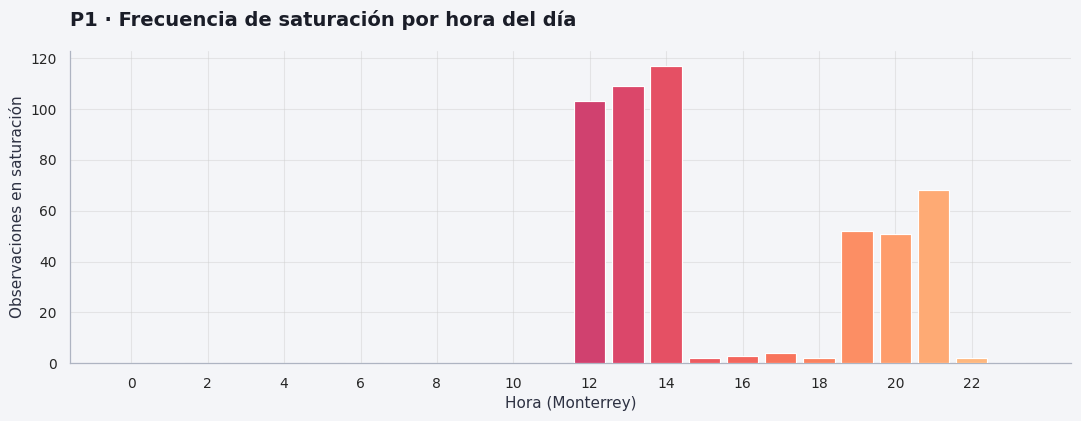

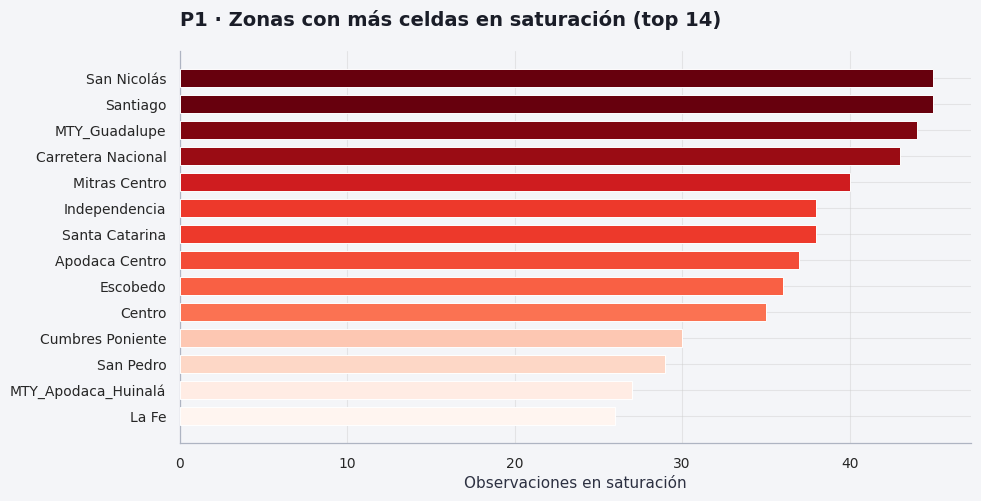

Top horas: HOUR
14    117
13    109
12    103
21     68
19     52
Top zonas:
ZONE
San Nicolás           45
Santiago              45
MTY_Guadalupe         44
Carretera Nacional    43
Mitras Centro         40
Independencia         38
Santa Catarina        38
Apodaca Centro        37
dtype: int64


In [31]:
# --- Estilo de figuras (por si no ejecutaste la celda de imports completa) ---
if "COLORS" not in globals():
    import matplotlib.pyplot as plt
    import numpy as np
    COLORS = {
        "p1_hours": plt.cm.magma(np.linspace(0.22, 0.88, 24)),
        "p1_zones_cmap": "Reds",
        "p3_bar": "#3d6b8e",
        "p4_face": "#2a9d8f",
        "p4_edge": "#1b4332",
        "sens_bar": "#1d3557",
    }
if "polish_axes" not in globals():
    def polish_axes(ax, title_pad=18):
        title = ax.get_title()
        ax.set_title("")
        ax.set_title(
            title,
            loc="left",
            pad=title_pad,
            fontsize=14,
            fontweight="600",
            color="#1a1d28",
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_linewidth(0.9)
            ax.spines[side].set_color("#aeb4c2")

sat = raw[raw["clasificacion"] == "saturacion"]
print(f"Horas en saturación: {len(sat)} / {len(raw)} ({100*len(sat)/len(raw):.2f}%)")

p1h = sat.groupby("HOUR").size().reindex(range(24), fill_value=0)
p1z = sat.groupby("ZONE").size().sort_values(ascending=False)

# P1a — barras por hora (gradiente por intensidad horaria)
fig, ax = plt.subplots(figsize=(11, 4.4), facecolor=plt.rcParams["figure.facecolor"])
ax.bar(
    p1h.index,
    p1h.values,
    color=COLORS["p1_hours"],
    edgecolor="white",
    linewidth=0.85,
    width=0.82,
    zorder=3,
)
ax.set_xlabel("Hora (Monterrey)")
ax.set_ylabel("Observaciones en saturación")
ax.set_title("P1 · Frecuencia de saturación por hora del día")
ax.set_xticks(range(0, 24, 2))
polish_axes(ax)
ax.grid(axis="y", zorder=0)
fig.tight_layout()
fig.savefig(FIG / "p1_horas_saturacion.png", dpi=175)
plt.show()

# P1b — zonas (tonos proporcionales al conteo)
fig, ax = plt.subplots(figsize=(10, 5.2), facecolor=plt.rcParams["figure.facecolor"])
topz = p1z.head(14)
norm = mcolors.Normalize(vmin=topz.min(), vmax=topz.max())
cmap = plt.get_cmap(COLORS["p1_zones_cmap"])
bar_colors = [cmap(norm(v)) for v in topz.values]
y_pos = np.arange(len(topz))
ax.barh(
    y_pos,
    topz.values,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.7,
    height=0.72,
    zorder=3,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(topz.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Observaciones en saturación")
ax.set_title("P1 · Zonas con más celdas en saturación (top 14)")
polish_axes(ax)
ax.grid(axis="x", zorder=0)
fig.tight_layout()
fig.savefig(FIG / "p1_zonas_saturacion.png", dpi=175)
plt.show()

print("Top horas:", p1h.nlargest(5).to_string())
print("Top zonas:")
print(p1z.head(8))


### P2 — Variable externa (precipitación)

**Nota:** Primero se mira la **matriz de correlación de Pearson** entre precipitación, ratio y earnings (asociación lineal bivariada). Luego un **MCO** `ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE)`: el coeficiente de precipitación es un efecto **marginal** con **hora y zona fijas**, para atenuar que la lluvia coincida con franjas de alta demanda o con zonas concretas. Revisa el **signo** del coeficiente y su **p-valor** para interpretar si más lluvia se asocia a más carga relativa (ratio), con esta especificación.

In [32]:
print(raw[["PRECIPITATION_MM", "ratio", "EARNINGS"]].corr(method="pearson"))

m = smf.ols("ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE)", data=raw).fit()
print(m.params["PRECIPITATION_MM"], m.pvalues["PRECIPITATION_MM"])
print(m.summary2().tables[0])

rain = raw["PRECIPITATION_MM"] > 0.5
print("P(saturación | precip>0.5):", raw.loc[rain, "clasificacion"].eq("saturacion").mean())
print("P(saturación | precip<=0.5):", raw.loc[~rain, "clasificacion"].eq("saturacion").mean())

                  PRECIPITATION_MM     ratio  EARNINGS
PRECIPITATION_MM          1.000000  0.318902  0.226029
ratio                     0.318902  1.000000  0.099885
EARNINGS                  0.226029  0.099885  1.000000
0.08060564022168862 4.254775042697023e-240
                     0                 1                    2          3
0               Model:               OLS      Adj. R-squared:      0.716
1  Dependent Variable:             ratio                 AIC:  3923.7092
2                Date:  2026-03-20 21:13                 BIC:  4198.0049
3    No. Observations:             10080      Log-Likelihood:    -1923.9
4            Df Model:                37         F-statistic:      689.1
5        Df Residuals:             10042  Prob (F-statistic):       0.00
6           R-squared:             0.717               Scale:   0.086088
P(saturación | precip>0.5): 0.3081632653061224
P(saturación | precip<=0.5): 0.037747653806047964


### P3 — Heterogeneidad por zona (sensibilidad a lluvia)

**Nota:** Se estima **por cada zona** un modelo `ratio ~ PRECIPITATION_MM + C(HOUR)` (misma idea que en P2 pero **sin** dummies de zona, porque cada regresión usa solo una zona). El gráfico muestra el **coeficiente marginal de precipitación** por zona: compara si la lluvia “empuja” el ratio de forma parecida en todas partes o si hay **zonas más sensibles** (pendientes mayores en valor absoluto).

                  ZONE  coef_precip_mm
0             Santiago        0.191517
1   Carretera Nacional        0.133912
2       Santa Catarina        0.102633
3  MTY_Apodaca_Huinalá        0.084674
4        Independencia        0.074754
5            San Pedro        0.067027
6             Escobedo        0.066836
7       Apodaca Centro        0.065833


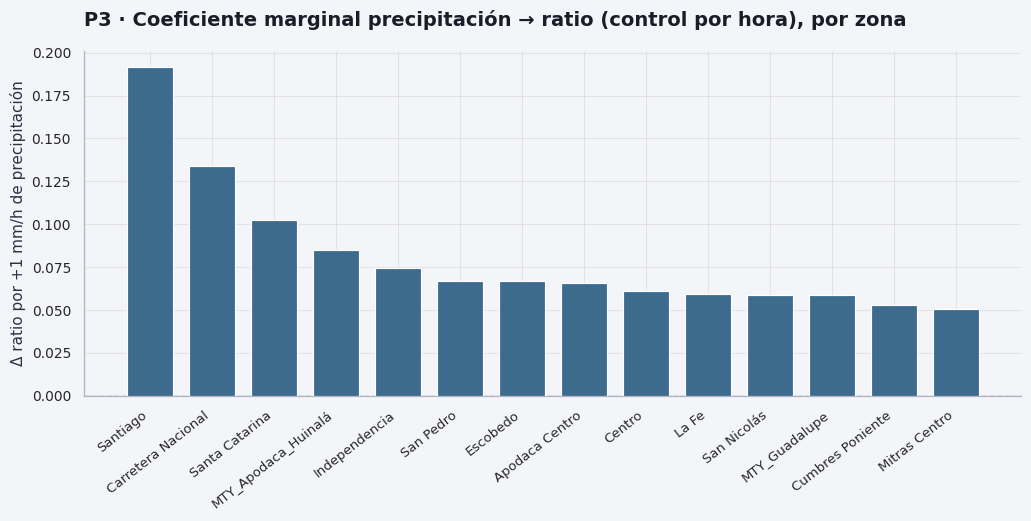

In [33]:
# --- Estilo de figuras (por si no ejecutaste la celda de imports completa) ---
if "COLORS" not in globals():
    import matplotlib.pyplot as plt
    import numpy as np
    COLORS = {
        "p1_hours": plt.cm.magma(np.linspace(0.22, 0.88, 24)),
        "p1_zones_cmap": "Reds",
        "p3_bar": "#3d6b8e",
        "p4_face": "#2a9d8f",
        "p4_edge": "#1b4332",
        "sens_bar": "#1d3557",
    }
if "polish_axes" not in globals():
    def polish_axes(ax, title_pad=18):
        title = ax.get_title()
        ax.set_title("")
        ax.set_title(
            title,
            loc="left",
            pad=title_pad,
            fontsize=14,
            fontweight="600",
            color="#1a1d28",
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_linewidth(0.9)
            ax.spines[side].set_color("#aeb4c2")

slopes = []
for z in sorted(raw["ZONE"].unique()):
    sub = raw[raw["ZONE"] == z]
    mz = smf.ols("ratio ~ PRECIPITATION_MM + C(HOUR)", data=sub).fit()
    slopes.append((z, float(mz.params["PRECIPITATION_MM"])))

slopes = sorted(slopes, key=lambda x: -abs(x[1]))
coef_df = pd.DataFrame(slopes, columns=["ZONE", "coef_precip_mm"])
print(coef_df.head(8))

fig, ax = plt.subplots(figsize=(10.5, 5.4), facecolor=plt.rcParams["figure.facecolor"])
x = np.arange(len(coef_df))
ax.bar(
    x,
    coef_df["coef_precip_mm"],
    color=COLORS["p3_bar"],
    edgecolor="white",
    linewidth=0.85,
    width=0.74,
    zorder=3,
)
ax.axhline(0, color="#8892a6", linewidth=1.0, linestyle="--", zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(coef_df["ZONE"], rotation=38, ha="right", fontsize=9.5)
ax.set_ylabel("Δ ratio por +1 mm/h de precipitación")
ax.set_title("P3 · Coeficiente marginal precipitación → ratio (control por hora), por zona")
polish_axes(ax)
ax.grid(axis="y", zorder=0)
fig.tight_layout()
fig.savefig(FIG / "p3_sensibilidad_zona.png", dpi=175)
plt.show()


### P4 — Calibración de earnings y posible gasto ineficiente

**Nota:** Se **agrega por día** (`DATE`): earnings medio del día, **fracción de filas en saturación** ese día (`sat_frac`) y ratio medio. Ordenar por `sat_frac` destaca **días con más estrés** operativo. La nube **earnings vs sat_frac** muestra si días “caros” en incentivos coinciden con mucha saturación. El bloque con **percentiles (p75)** identifica días con **earn alto** y **sat_frac alto** a la vez — candidatos a **desalineación** entre coste de earnings y presión operativa (a interpretar con cautela: son heurísticos, no prueba causal).

Días con mayor fracción de horas saturadas (top 10):
          DATE  earn_mean  sat_frac  ratio_mean
27  2024-03-28  55.863393  0.166667    1.102925
7   2024-03-08  56.218155  0.139881    0.975630
24  2024-03-25  56.071131  0.130952    0.896001
4   2024-03-05  57.172917  0.095238    0.979752
26  2024-03-27  56.660714  0.065476    0.809092
13  2024-03-14  60.444940  0.050595    0.746482
15  2024-03-16  57.166369  0.050595    0.800138
0   2024-03-01  56.587500  0.047619    0.830797
17  2024-03-18  56.638393  0.044643    0.814346
25  2024-03-26  56.550595  0.044643    0.816600

Días candidatos a desalineación earn vs estrés (p75 earn y p75 sat_frac):
          DATE  earn_mean  sat_frac
13  2024-03-14   60.44494  0.050595


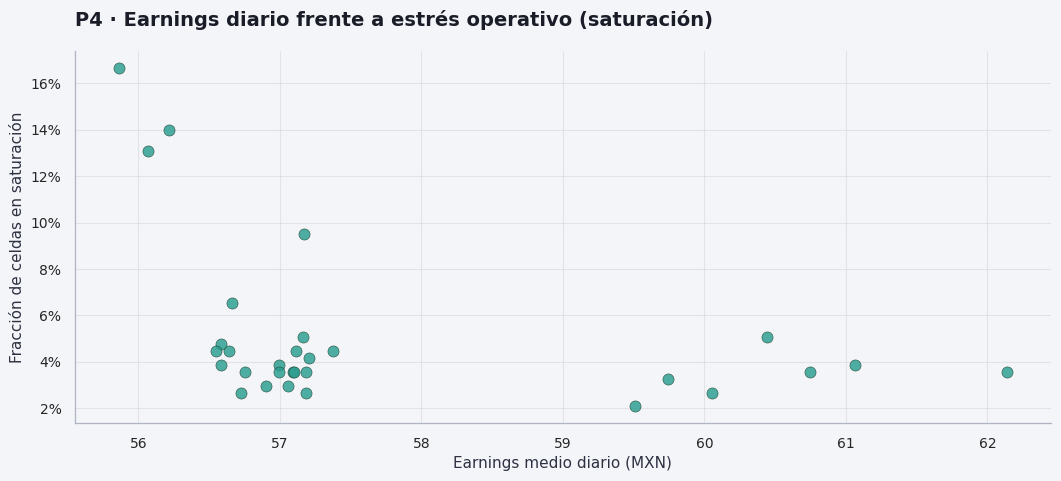

In [34]:
# --- Estilo de figuras (por si no ejecutaste la celda de imports completa) ---
if "COLORS" not in globals():
    import matplotlib.pyplot as plt
    import numpy as np
    COLORS = {
        "p1_hours": plt.cm.magma(np.linspace(0.22, 0.88, 24)),
        "p1_zones_cmap": "Reds",
        "p3_bar": "#3d6b8e",
        "p4_face": "#2a9d8f",
        "p4_edge": "#1b4332",
        "sens_bar": "#1d3557",
    }
if "polish_axes" not in globals():
    def polish_axes(ax, title_pad=18):
        title = ax.get_title()
        ax.set_title("")
        ax.set_title(
            title,
            loc="left",
            pad=title_pad,
            fontsize=14,
            fontweight="600",
            color="#1a1d28",
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_linewidth(0.9)
            ax.spines[side].set_color("#aeb4c2")

daily = raw.groupby("DATE").agg(
    earn_mean=("EARNINGS", "mean"),
    sat_frac=("clasificacion", lambda s: (s == "saturacion").mean()),
    ratio_mean=("ratio", "mean"),
).reset_index()

daily = daily.sort_values("sat_frac", ascending=False)
print("Días con mayor fracción de horas saturadas (top 10):")
print(daily.head(10))

p75 = daily["earn_mean"].quantile(0.75)
stress = daily["sat_frac"] >= daily["sat_frac"].quantile(0.75)
ineff = daily[(daily["earn_mean"] >= p75) & stress]
print("\nDías candidatos a desalineación earn vs estrés (p75 earn y p75 sat_frac):")
print(ineff[["DATE", "earn_mean", "sat_frac"]])

fig, ax = plt.subplots(figsize=(10.8, 5), facecolor=plt.rcParams["figure.facecolor"])
ax.scatter(
    daily["earn_mean"],
    daily["sat_frac"],
    s=64,
    alpha=0.82,
    c=COLORS["p4_face"],
    edgecolors=COLORS["p4_edge"],
    linewidths=0.45,
    zorder=3,
)
ax.set_xlabel("Earnings medio diario (MXN)")
ax.set_ylabel("Fracción de celdas en saturación")
ax.set_title("P4 · Earnings diario frente a estrés operativo (saturación)")
polish_axes(ax)
ax.grid(True, zorder=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
fig.tight_layout()
fig.savefig(FIG / "p4_earnings_vs_estres.png", dpi=175)
plt.show()


### P5 — Relación earnings–saturación con interacción (lluvia)

**Nota:** **Spearman** mide asociación **monótona** (no solo lineal) entre earnings y ratio, global y en el subconjunto con **precipitación > 0**. El modelo **OLS** con término **EARNINGS × PRECIPITATION_MM** (más controles de hora y zona) permite ver si la pendiente de ratio respecto a earnings **depende** de cuánto llueve. Una interacción significativa sugiere que la relación incentivo–carga relativa **cambia bajo lluvia**; interpreta coeficientes en escala de las variables.

In [35]:
print("Spearman earnings vs ratio (global):", spearmanr(raw["EARNINGS"], raw["ratio"]))
mask = raw["PRECIPITATION_MM"] > 0
print("Con precip>0:", spearmanr(raw.loc[mask, "EARNINGS"], raw.loc[mask, "ratio"]))

m5 = smf.ols("ratio ~ EARNINGS * PRECIPITATION_MM + C(HOUR) + C(ZONE)", data=raw).fit()
print(m5.params["EARNINGS"], m5.params["EARNINGS:PRECIPITATION_MM"])

Spearman earnings vs ratio (global): SignificanceResult(statistic=np.float64(0.07613533003613025), pvalue=np.float64(1.9468694077848612e-14))
Con precip>0: SignificanceResult(statistic=np.float64(-0.2509179807834915), pvalue=np.float64(2.6791141022556686e-10))
-0.024943005163521048 -0.0018947792121322992


### Análisis de sensibilidad (1.2 → 1.8 en ratio)

**Nota:** Con el modelo por zona `ratio ~ PRECIPITATION_MM + C(HOUR)` se obtiene un coeficiente marginal $\beta_z$ (efecto lineal local de la lluvia). Si se interpreta el tramo “saludable” alto en **1.2** y la **saturación** en **1.8**, el salto es $\Delta\rho = 0.6$. La aproximación $\Delta\rho \approx \beta_z \cdot \Delta\text{precip}$ implica $\Delta\text{precip} \approx 0.6/\beta_z$ (si $\beta_z \neq 0$): son **mm/h adicionales** de orden de magnitud para ese paso, no una predicción exacta (linealidad, controles limitados, sin no linealidades).

,ZONE,beta_precip,mm_for_0_6_ratio
13,Santiago,0.191517,3.132878
1,Carretera Nacional,0.133912,4.480568
12,Santa Catarina,0.102633,5.846053
7,MTY_Apodaca_Huinalá,0.084674,7.086019
5,Independencia,0.074754,8.026371
11,San Pedro,0.067027,8.951625
4,Escobedo,0.066836,8.977235
0,Apodaca Centro,0.065833,9.113931
2,Centro,0.061034,9.830606
6,La Fe,0.059015,10.166982


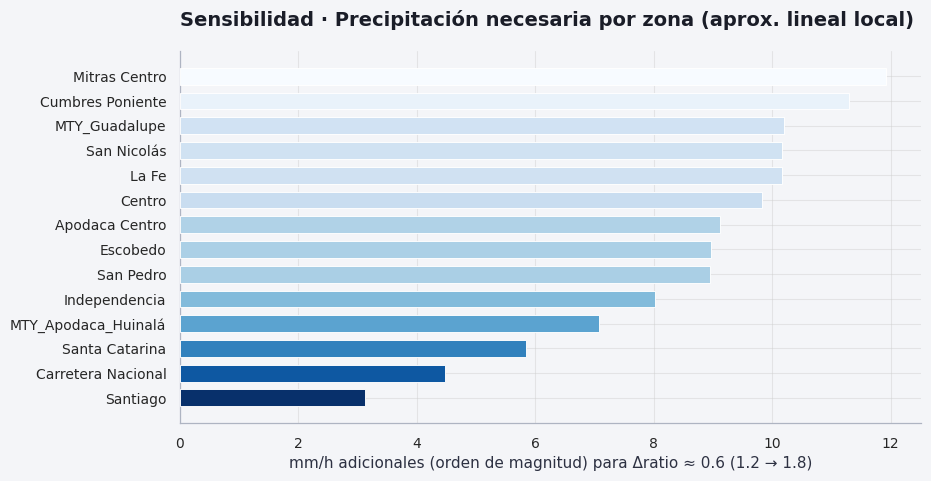

In [36]:
# --- Estilo de figuras (por si no ejecutaste la celda de imports completa) ---
if "COLORS" not in globals():
    import matplotlib.pyplot as plt
    import numpy as np
    COLORS = {
        "p1_hours": plt.cm.magma(np.linspace(0.22, 0.88, 24)),
        "p1_zones_cmap": "Reds",
        "p3_bar": "#3d6b8e",
        "p4_face": "#2a9d8f",
        "p4_edge": "#1b4332",
        "sens_bar": "#1d3557",
    }
if "polish_axes" not in globals():
    def polish_axes(ax, title_pad=18):
        title = ax.get_title()
        ax.set_title("")
        ax.set_title(
            title,
            loc="left",
            pad=title_pad,
            fontsize=14,
            fontweight="600",
            color="#1a1d28",
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_linewidth(0.9)
            ax.spines[side].set_color("#aeb4c2")

coefs = []
for z in sorted(raw["ZONE"].unique()):
    sub = raw[raw["ZONE"] == z]
    mz = smf.ols("ratio ~ PRECIPITATION_MM + C(HOUR)", data=sub).fit()
    b = float(mz.params["PRECIPITATION_MM"])
    delta_mm = (0.6 / b) if b > 1e-8 else np.nan
    coefs.append({"ZONE": z, "beta_precip": b, "mm_for_0_6_ratio": delta_mm})

sens_df = pd.DataFrame(coefs).sort_values("mm_for_0_6_ratio")
display(sens_df.head(14))

plot_df = sens_df.dropna(subset=["mm_for_0_6_ratio"]).copy()
fig, ax = plt.subplots(figsize=(9.5, 5), facecolor=plt.rcParams["figure.facecolor"])
norm = mcolors.Normalize(
    vmin=plot_df["mm_for_0_6_ratio"].min(),
    vmax=plot_df["mm_for_0_6_ratio"].max(),
)
cmap = plt.cm.Blues_r
bar_colors = [cmap(norm(v)) for v in plot_df["mm_for_0_6_ratio"]]
y_pos = np.arange(len(plot_df))
ax.barh(
    y_pos,
    plot_df["mm_for_0_6_ratio"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.65,
    height=0.68,
    zorder=3,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["ZONE"], fontsize=10)
ax.set_xlabel("mm/h adicionales (orden de magnitud) para Δratio ≈ 0.6 (1.2 → 1.8)")
ax.set_title("Sensibilidad · Precipitación necesaria por zona (aprox. lineal local)")
polish_axes(ax)
ax.grid(axis="x", zorder=0)
fig.tight_layout()
fig.savefig(FIG / "p_sensitivity_mm_12_to_18.png", dpi=175)
plt.show()
